# General Statistics

input: preprocessed datasets (TSV format)

Import libraries

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

Package installation

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Load preprocessed dataset

In [ ]:
year = 2021
category = 'economics'

df = pd.read_csv(f'/content/sample_data/pravda_preprocessed_{year}_{category}.tsv', sep='\t')
df

,url,category,title,lead,paragraphs,lemmatized_paragraphs
0,https://www.pravda.ru/news/economics/1590649-b...,economics,"Эксперт рассказал, в каких случаях банк внезап...",Глава Ассоциации участников рынка электронных ...,Глава Ассоциации участников рынка электронных ...,глава ассоциация участник рынок электронный де...
1,https://www.pravda.ru/news/economics/1587109-u...,economics,"Экономист предсказал ""африканские"" зарплаты ук...",Заявление украинского премьераДениса Шмыгаляо ...,Заявление украинского премьераДениса Шмыгаляо ...,заявление украинского премьерадениса шмыгаляо ...
2,https://www.pravda.ru/news/economics/1626707-b...,economics,Семь бед - одна вакцина: что нужно для снижени...,"Пандемия, помимо прочих бед, ""подарила"" России...","Пандемия, помимо прочих бед, ""подарила"" России...",пандемия прочих беда подарить россия ирост без...
3,https://www.pravda.ru/news/economics/1611769-g...,economics,Россия продала почти все долгосрочные гособлиг...,Согласно новым даннымМинистерства финансов США...,Согласно новым даннымМинистерства финансов США...,Согласно новый даннымминистерства финансов сша...
4,https://www.pravda.ru/news/economics/1614402-k...,economics,Экономисты предупредили о желании властей конт...,Государство стремится ужесточить контроль за д...,Государство стремится ужесточить контроль за д...,государство стремиться ужесточить контроль ден...
...,...,...,...,...,...,...
2179,https://www.pravda.ru/news/economics/1580779-k...,economics,"Новая задумка властей: ""раскрашивание"" клиенто...","Очередная попытка уменьшить число ""отмываемых""...","Очередная попытка уменьшить число ""отмываемых""...",очередной попытка уменьшить число отмывать пут...
2180,https://www.pravda.ru/news/economics/1593617-b...,economics,"""Всё выше, и выше, и выше"": биткоин штурмует н...","Продолжающийся ""разгон"" биткоина, который на д...","Продолжающийся ""разгон"" биткоина, который на д...",продолжающийся разгон биткоина день преодолеть...
2181,https://www.pravda.ru/economics/1671400-litvak...,economics,"В Литве подсчитали, во сколько обходится проти...",Руководитель Литовской конфедерации промышленн...,Руководитель Литовской конфедерации промышленн...,руководитель литовский конфедерация промышленн...
2182,https://www.pravda.ru/news/economics/1662614-m...,economics,"У Молдавии есть большие трудности с выплатой ""...","У компании""Молдовагаз""пока нет ответа, каким о...","У компании""Молдовагаз""пока нет ответа, каким о...","компании""молдовагаз""пока ответ образ выплатить..."


Total documents

In [ ]:
df.shape[0]

2184

A function to count tokens

In [ ]:
def count_tokens(document):
  tokens = word_tokenize(document)
  return len(tokens)

Count tokens

In [ ]:
df['n_tokens'] = df['paragraphs'].apply(count_tokens)
df.head()

,url,category,title,lead,paragraphs,lemmatized_paragraphs,n_tokens
0,https://www.pravda.ru/news/economics/1590649-b...,economics,"Эксперт рассказал, в каких случаях банк внезап...",Глава Ассоциации участников рынка электронных ...,Глава Ассоциации участников рынка электронных ...,глава ассоциация участник рынок электронный де...,127
1,https://www.pravda.ru/news/economics/1587109-u...,economics,"Экономист предсказал ""африканские"" зарплаты ук...",Заявление украинского премьераДениса Шмыгаляо ...,Заявление украинского премьераДениса Шмыгаляо ...,заявление украинского премьерадениса шмыгаляо ...,82
2,https://www.pravda.ru/news/economics/1626707-b...,economics,Семь бед - одна вакцина: что нужно для снижени...,"Пандемия, помимо прочих бед, ""подарила"" России...","Пандемия, помимо прочих бед, ""подарила"" России...",пандемия прочих беда подарить россия ирост без...,258
3,https://www.pravda.ru/news/economics/1611769-g...,economics,Россия продала почти все долгосрочные гособлиг...,Согласно новым даннымМинистерства финансов США...,Согласно новым даннымМинистерства финансов США...,Согласно новый даннымминистерства финансов сша...,177
4,https://www.pravda.ru/news/economics/1614402-k...,economics,Экономисты предупредили о желании властей конт...,Государство стремится ужесточить контроль за д...,Государство стремится ужесточить контроль за д...,государство стремиться ужесточить контроль ден...,185


Shortest document

In [ ]:
df['n_tokens'].min()

42

Longest document

In [ ]:
df['n_tokens'].max()

3181

Average tokens per document

In [ ]:
df['n_tokens'].mean()

np.float64(304.1465201465202)

Plot documents by number of tokens (boxplot)

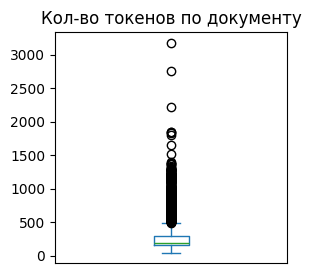

In [ ]:
df['n_tokens'].plot(kind='box', figsize=(3, 3), title='Кол-во токенов по документу', xticks=[]);

Inspect for outliers (for example, documents with too many tokens)

In [ ]:
df[df['n_tokens'] > 8000]

,url,category,title,lead,paragraphs,lemmatized_paragraphs,n_tokens
